In [1]:
# Local notebook setup (reads files from current working directory)
import os
import numpy as np  # linear algebra
import pandas as pd  # data processing, CSV file I/O

print("Current working directory:", os.getcwd())
print("Files in directory:")
for filename in os.listdir(os.getcwd()):
    print(" -", filename)

Current working directory: c:\Users\sumit\Downloads\Desktop\mp-code
Files in directory:
 - gold-dataset-sinha-khandait.csv
 - mp-code.ipynb
 - test_headlines.md
 - XAU_INR Historical Data.csv


## Colab Setup: Install Required Libraries

Run the next cell once when you open this notebook in Google Colab.

In [2]:
# Run this once in Colab
%pip install -q --upgrade pip
%pip install -q numpy pandas scikit-learn matplotlib seaborn nltk ipywidgets joblib scipy
%pip install -q xgboost tensorflow sentence-transformers

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error, accuracy_score
import matplotlib.pyplot as plt
import joblib

try:
    import tensorflow as tf
    from tensorflow.keras.layers import Input, Dense, LSTM, Dropout, concatenate
    from tensorflow.keras.models import Model
except ModuleNotFoundError:
    tf = None
    Input = Dense = LSTM = Dropout = concatenate = Model = None

try:
    from sentence_transformers import SentenceTransformer
except ModuleNotFoundError:
    SentenceTransformer = None

In [4]:
# Load datasets from current working directory (not Kaggle input)
data2 = pd.read_csv("XAU_INR Historical Data.csv")
data1 = pd.read_csv("gold-dataset-sinha-khandait.csv")

data2.head(5)

,Date,Price,Open,High,Low,Vol.,Change %
0,03/25/2019,"91,046","90,845","91,250","90,586",NaN,0.25%
1,03/22/2019,"90,816","90,099","90,875","89,662",NaN,0.82%
2,03/21/2019,"90,074","90,283","90,750","89,578",NaN,-0.20%
3,03/20/2019,"90,251","90,176","90,599","89,423",NaN,0.11%
4,03/19/2019,"90,148","89,469","90,456","89,362",NaN,0.79%


In [5]:
data1.head(5)

,Dates,URL,News,Price Direction Up,Price Direction Constant,Price Direction Down,Asset Comparision,Past Information,Future Information,Price Sentiment
0,28-01-2016,http://www.marketwatch.com/story/april-gold-do...,"april gold down 20 cents to settle at $1,116.1...",0,0,1,0,1,0,negative
1,13-09-2017,http://www.marketwatch.com/story/gold-prices-s...,gold suffers third straight daily decline,0,0,1,0,1,0,negative
2,26-07-2016,http://www.marketwatch.com/story/gold-futures-...,Gold futures edge up after two-session decline,1,0,0,0,1,0,positive
3,28-02-2018,https://www.metalsdaily.com/link/277199/dent-r...,dent research : is gold's day in the sun comin...,0,0,0,0,0,1,none
4,06-09-2017,http://www.marketwatch.com/story/gold-steadies...,"Gold snaps three-day rally as Trump, lawmakers...",0,0,1,0,1,0,negative


In [6]:
column1_name = "Dates"
date_format1 = "%d-%m-%Y"
data1["Dates"] = data1["Dates"].astype(str).str.strip()
data1[column1_name] = pd.to_datetime(data1[column1_name], format=date_format1,errors='coerce')

In [7]:

column2_name = "Date"
date_format2 = "%m/%d/%Y"
data2["Date"] = data2["Date"].astype(str).str.strip()
data2[column2_name] = pd.to_datetime(data2[column2_name],  format=date_format2,errors='coerce')

In [8]:
data2 = data2.rename(columns={"Date": "Dates"})
# # Convert the 'Dates' column in data2 to datetime after renaming
data2["Dates"] = pd.to_datetime(data2["Dates"], format=date_format2, errors='coerce')

df = pd.merge(data1, data2,
                   on='Dates',
                   how='inner')

In [9]:

df.head(10)

,Dates,URL,News,Price Direction Up,Price Direction Constant,Price Direction Down,Asset Comparision,Past Information,Future Information,Price Sentiment,Price,Open,High,Low,Vol.,Change %
0,2016-01-28,http://www.marketwatch.com/story/april-gold-do...,"april gold down 20 cents to settle at $1,116.1...",0,0,1,0,1,0,negative,"75,847","76,672","76,780","75,689",NaN,-1.02%
1,2017-09-13,http://www.marketwatch.com/story/gold-prices-s...,gold suffers third straight daily decline,0,0,1,0,1,0,negative,"84,597","85,285","85,451","84,542",NaN,-0.73%
2,2016-07-26,http://www.marketwatch.com/story/gold-futures-...,Gold futures edge up after two-session decline,1,0,0,0,1,0,positive,"88,849","88,688","89,176","88,558",NaN,0.23%
3,2018-02-28,https://www.metalsdaily.com/link/277199/dent-r...,dent research : is gold's day in the sun comin...,0,0,0,0,0,1,none,"85,917","85,561","86,261","85,408",NaN,0.41%
4,2017-09-06,http://www.marketwatch.com/story/gold-steadies...,"Gold snaps three-day rally as Trump, lawmakers...",0,0,1,0,1,0,negative,"85,434","85,864","86,106","85,301",NaN,-0.41%
5,2016-08-16,http://www.marketwatch.com/story/dec-gold-clim...,"Dec. gold climbs $9.40, or 0.7%, to settle at ...",1,0,0,0,1,0,positive,"89,974","89,556","90,613","89,556",NaN,0.53%
6,2013-09-24,https://economictimes.indiatimes.com/markets/c...,"gold falls by rs 25 on sluggish demand, global...",0,0,1,0,1,0,negative,"83,034","82,723","83,469","81,979",NaN,0.38%
7,2016-09-23,http://www.marketwatch.com/story/gold-futures-...,"Gold futures fall for the session, but gain fo...",1,0,1,0,1,0,positive,"89,187","89,111","89,356","88,894",NaN,0.15%
8,2018-03-16,http://www.marketwatch.com/story/april-gold-ho...,"april gold holds slight gain, up $2.50, or 0.2...",1,0,0,0,1,0,positive,"85,319","85,563","85,855","85,043",NaN,-0.22%
9,2009-02-04,http://www.marketwatch.com/story/feb-gold-ends...,"feb. gold ends up $9.60, or 1.1%, at $901.60 a...",1,0,0,0,1,0,positive,"44,065","43,674","44,250","43,209",NaN,0.79%


In [10]:
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df = df.sort_values('Dates').reset_index(drop=True)

In [11]:
df.head(5)

,Dates,URL,News,Price Direction Up,Price Direction Constant,Price Direction Down,Asset Comparision,Past Information,Future Information,Price Sentiment,Price,Open,High,Low,Vol.,Change %
0,2000-02-15,http://www.marketwatch.com/story/thom-calandra...,gold is poised for greatness,1,0,0,0,1,0,positive,13124.0,13400.0,13424.0,13077.0,NaN,-1.93%
1,2000-02-17,http://www.marketwatch.com/story/gold-falls-on...,gold falls on technical pull back,0,0,1,0,1,0,negative,13090.0,13136.0,13457.0,12922.0,NaN,-0.31%
2,2000-03-24,http://www.marketwatch.com/story/gold-quiet-on...,gold quiet on lack of market news,0,1,0,0,1,0,neutral,12376.0,12390.0,12426.0,12354.0,NaN,-0.27%
3,2000-04-27,http://www.marketwatch.com/story/gold-futures-...,gold futures steady as index climbs,0,1,0,0,1,0,neutral,12055.0,12017.0,12086.0,11980.0,NaN,0.39%
4,2000-05-04,http://www.marketwatch.com/story/gold-and-silv...,gold and silver stocks in relief rally,1,0,0,1,1,0,positive,12192.0,12132.0,12328.0,12047.0,NaN,0.63%


In [12]:

mapping = {'negative': -1, 'neutral': 0, 'positive': 1, 'none': 0}
df['Price Sentiment'] = df['Price Sentiment'].astype(str).map(lambda x: mapping.get(x.lower(), 0))
df[['Dates', 'News', 'Price', 'Price Sentiment']].head()

,Dates,News,Price,Price Sentiment
0,2000-02-15,gold is poised for greatness,13124.0,1
1,2000-02-17,gold falls on technical pull back,13090.0,-1
2,2000-03-24,gold quiet on lack of market news,12376.0,0
3,2000-04-27,gold futures steady as index climbs,12055.0,0
4,2000-05-04,gold and silver stocks in relief rally,12192.0,1


In [13]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer


nltk.download("stopwords")
stop_words = set(stopwords.words("english"))
ps = PorterStemmer()

# cleaning function

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    words = text.split()
    words = [ps.stem(w) for w in words if w not in stop_words]
    return " ".join(words)
    

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sumit\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [14]:
df["News"] = df["News"].apply(clean_text)

In [15]:
df[['Dates', 'News','Open', 'Price','Change %', 'Price Sentiment']].head()

,Dates,News,Open,Price,Change %,Price Sentiment
0,2000-02-15,gold pois great,13400.0,13124.0,-1.93%,1
1,2000-02-17,gold fall technic pull back,13136.0,13090.0,-0.31%,-1
2,2000-03-24,gold quiet lack market news,12390.0,12376.0,-0.27%,0
3,2000-04-27,gold futur steadi index climb,12017.0,12055.0,0.39%,0
4,2000-05-04,gold silver stock relief ralli,12132.0,12192.0,0.63%,1


In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack

try:
    from xgboost import XGBRegressor
except ModuleNotFoundError:
    XGBRegressor = None

In [17]:
# ----- Basic cleaning -----
df["Dates"] = pd.to_datetime(df["Dates"])

# Numeric Change %
df["Change_num"] = (
    df["Change %"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .str.strip()
    .replace("", np.nan)
    .astype(float)
)

# Sort by date (VERY important for time-series)
df = df.sort_values("Dates").reset_index(drop=True)

# ----- Date features -----
df["Year"] = df["Dates"].dt.year
df["Month"] = df["Dates"].dt.month
df["Day"] = df["Dates"].dt.day

# ----- Lag features -----
df["Prev_Close"] = df["Price"].shift(1)
df["Prev_Open"] = df["Open"].shift(1)
df["Prev_Change"] = df["Change_num"].shift(1)

# ----- Rolling window features (using closing price) -----
df["MA_3"] = df["Price"].rolling(window=3).mean()
df["MA_7"] = df["Price"].rolling(window=7).mean()
df["STD_3"] = df["Price"].rolling(window=3).std()

# Drop rows that have NaN due to lag/rolling
df = df.dropna(subset=[
    "News", "Open", "Price", "Change_num",
    "Prev_Close", "Prev_Open", "Prev_Change",
    "MA_3", "MA_7", "STD_3"
]).reset_index(drop=True)


In [18]:
feature_cols_num = [
    "Open", "Prev_Close", "Prev_Open", "Prev_Change",
    "MA_3", "MA_7", "STD_3",
    "Year", "Month", "Day"
]

X = df[["News"] + feature_cols_num]
y = df[["Price", "Change_num"]]


In [19]:
y.head(5)

,Price,Change_num
0,12026.0,0.31
1,12122.0,0.27
2,12815.0,-0.40
3,12749.0,-0.04
4,12710.0,-0.30


In [20]:
n = len(df)
train_size = int(n * 0.8)

X_train = X.iloc[:train_size].copy()
y_train = y.iloc[:train_size].copy()
X_test = X.iloc[train_size:].copy()
y_test = y.iloc[train_size:].copy()

test_df = df.iloc[train_size:].copy()   # keep for building comparison table later


In [21]:
# Prepare text + numeric inputs
text_train = X_train["News"].fillna("").astype(str)
text_test = X_test["News"].fillna("").astype(str)

num_train = X_train[feature_cols_num].astype(float).values
num_test = X_test[feature_cols_num].astype(float).values

num_scaler = StandardScaler()
num_train_scaled = num_scaler.fit_transform(num_train)
num_test_scaled = num_scaler.transform(num_test)

# 1) XGBoost on TF-IDF + numeric
tfidf = TfidfVectorizer(max_features=12000, ngram_range=(1, 2), min_df=2, max_df=0.98)
x_text_train = tfidf.fit_transform(text_train)
x_text_test = tfidf.transform(text_test)

xgb_train_matrix = hstack([x_text_train, num_train_scaled])
xgb_test_matrix = hstack([x_text_test, num_test_scaled])

xgb_model = None
if XGBRegressor is not None:
    xgb_model = MultiOutputRegressor(
        XGBRegressor(
            n_estimators=600,
            learning_rate=0.03,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        )
    )

# 2) BERT embeddings + XGBoost
bert_encoder = None
bert_model = None
bert_train_matrix = None
bert_test_matrix = None
if SentenceTransformer is not None and XGBRegressor is not None:
    bert_encoder = SentenceTransformer("all-MiniLM-L6-v2")
    bert_train_emb = bert_encoder.encode(text_train.tolist(), convert_to_numpy=True, show_progress_bar=True)
    bert_test_emb = bert_encoder.encode(text_test.tolist(), convert_to_numpy=True, show_progress_bar=True)

    bert_train_matrix = np.hstack([bert_train_emb, num_train_scaled])
    bert_test_matrix = np.hstack([bert_test_emb, num_test_scaled])

    bert_model = MultiOutputRegressor(
        XGBRegressor(
            n_estimators=500,
            learning_rate=0.03,
            max_depth=5,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        )
    )

# 3) LSTM on tokenized headlines + numeric features
lstm_model = None
tokenizer = None
seq_train = seq_test = None
if tf is not None:
    max_words = 20000
    max_len = 80

    tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=max_words, oov_token="<OOV>")
    tokenizer.fit_on_texts(text_train.tolist())

    seq_train = tf.keras.preprocessing.sequence.pad_sequences(
        tokenizer.texts_to_sequences(text_train.tolist()), maxlen=max_len, padding="post", truncating="post"
    )
    seq_test = tf.keras.preprocessing.sequence.pad_sequences(
        tokenizer.texts_to_sequences(text_test.tolist()), maxlen=max_len, padding="post", truncating="post"
    )

    text_input = tf.keras.layers.Input(shape=(max_len,), name="text_input")
    text_branch = tf.keras.layers.Embedding(max_words, 128)(text_input)
    text_branch = tf.keras.layers.LSTM(64, dropout=0.2, recurrent_dropout=0.2)(text_branch)

    num_input = tf.keras.layers.Input(shape=(num_train_scaled.shape[1],), name="num_input")
    num_branch = tf.keras.layers.Dense(32, activation="relu")(num_input)

    merged = tf.keras.layers.concatenate([text_branch, num_branch])
    merged = tf.keras.layers.Dense(64, activation="relu")(merged)
    merged = tf.keras.layers.Dropout(0.2)(merged)
    output = tf.keras.layers.Dense(2, name="reg_output")(merged)

    lstm_model = tf.keras.Model(inputs=[text_input, num_input], outputs=output)
    lstm_model.compile(optimizer="adam", loss="mse", metrics=["mae"])

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/251 [00:00<?, ?it/s]

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

In [22]:
trained_models = {}
model_outputs = {}

# Train XGBoost model
if xgb_model is not None:
    xgb_model.fit(xgb_train_matrix, y_train.values)
    model_outputs["XGBoost"] = xgb_model.predict(xgb_test_matrix)
    trained_models["XGBoost"] = xgb_model

# Train BERT + XGBoost model
if bert_model is not None:
    bert_model.fit(bert_train_matrix, y_train.values)
    model_outputs["BERT+XGBoost"] = bert_model.predict(bert_test_matrix)
    trained_models["BERT+XGBoost"] = bert_model

# Train LSTM model
if lstm_model is not None:
    lstm_model.fit(
        [seq_train, num_train_scaled],
        y_train.values,
        validation_split=0.1,
        epochs=10,
        batch_size=32,
        verbose=1
    )
    model_outputs["LSTM"] = lstm_model.predict([seq_test, num_test_scaled], verbose=0)
    trained_models["LSTM"] = lstm_model

if len(model_outputs) == 0:
    raise RuntimeError(
        "No model could be trained. Install xgboost/tensorflow/sentence-transformers first."
    )

# Select best model using RMSE on Price
price_true_eval = y_test["Price"].values
model_rmse = {}
for model_name, model_pred in model_outputs.items():
    model_rmse[model_name] = float(np.sqrt(mean_squared_error(price_true_eval, model_pred[:, 0])))

best_model_name = min(model_rmse, key=model_rmse.get)
model = trained_models[best_model_name]  # kept for compatibility with later cells
preds = model_outputs[best_model_name]

print("Trained models:", list(model_outputs.keys()))
print("Selected best model:", best_model_name)
print("Best model RMSE (Price):", round(model_rmse[best_model_name], 4))

Epoch 1/10
226/226 ━━━━━━━━━━━━━━━━━━━━ 32s 105ms/step - loss: 2410928384.0000 - mae: 32305.6602 - val_loss: 3281779456.0000 - val_mae: 40497.7070
Epoch 2/10
226/226 ━━━━━━━━━━━━━━━━━━━━ 22s 98ms/step - loss: 2336108032.0000 - mae: 31731.1816 - val_loss: 3090070784.0000 - val_mae: 39297.5156
Epoch 3/10
226/226 ━━━━━━━━━━━━━━━━━━━━ 22s 97ms/step - loss: 2116980352.0000 - mae: 30008.4219 - val_loss: 2650419712.0000 - val_mae: 36396.6797
Epoch 4/10
226/226 ━━━━━━━━━━━━━━━━━━━━ 25s 109ms/step - loss: 1731641344.0000 - mae: 26756.3496 - val_loss: 1987307264.0000 - val_mae: 31519.3848
Epoch 5/10
226/226 ━━━━━━━━━━━━━━━━━━━━ 26s 116ms/step - loss: 1247005312.0000 - mae: 22411.7344 - val_loss: 1238000896.0000 - val_mae: 24878.6914
Epoch 6/10
226/226 ━━━━━━━━━━━━━━━━━━━━ 26s 113ms/step - loss: 781425984.0000 - mae: 17858.6543 - val_loss: 596109760.0000 - val_mae: 17253.7051
Epoch 7/10
226/226 ━━━━━━━━━━━━━━━━━━━━ 25s 111ms/step - loss: 429897600.0000 - mae: 13156.9375 - val_loss: 197601392.0000

In [23]:
import seaborn as sns

sns.set(style="whitegrid")

In [24]:
price_true = y_test["Price"].values
change_true = y_test["Change_num"].values

price_pred = preds[:, 0]
change_pred = preds[:, 1]

# Metrics for selected best model
rmse_price = np.sqrt(mean_squared_error(price_true, price_pred))
r2_price = r2_score(price_true, price_pred)

rmse_change = np.sqrt(mean_squared_error(change_true, change_pred))
r2_change = r2_score(change_true, change_pred)

print("===== Selected Model Metrics =====")
print("Model Name:", best_model_name)
print("RMSE Price:", rmse_price)
print("R2 Price:", r2_price)
print("RMSE Change %:", rmse_change)
print("R2 Change %:", r2_change)

# Compare all trained models
metrics_rows = []
for model_name, model_pred in model_outputs.items():
    metrics_rows.append({
        "Model": model_name,
        "RMSE Price": np.sqrt(mean_squared_error(price_true, model_pred[:, 0])),
        "R2 Price": r2_score(price_true, model_pred[:, 0]),
        "RMSE Change %": np.sqrt(mean_squared_error(change_true, model_pred[:, 1])),
        "R2 Change %": r2_score(change_true, model_pred[:, 1]),
    })

metrics_df = pd.DataFrame(metrics_rows).sort_values("RMSE Price").reset_index(drop=True)
print("\n===== Model Comparison =====")
display(metrics_df)

===== Selected Model Metrics =====
Model Name: XGBoost
RMSE Price: 190.50048978314916
R2 Price: 0.9939442268815314
RMSE Change %: 0.33381193184822694
R2 Change %: 0.7153760567174019

===== Model Comparison =====


,Model,RMSE Price,R2 Price,RMSE Change %,R2 Change %
0,XGBoost,190.500490,0.993944,0.333812,0.715376
1,BERT+XGBoost,195.042272,0.993652,0.336355,0.711023
2,LSTM,12491.215656,-25.036753,2.519036,-15.208258


In [25]:
def change_to_sentiment(x):
    if x > 0:
        return 1
    elif x < 0:
        return -1
    else:
        return 0

true_sent = np.array([change_to_sentiment(c) for c in change_true])
pred_sent = np.array([change_to_sentiment(c) for c in change_pred])

sent_acc = accuracy_score(true_sent, pred_sent)

print("\n===== Sentiment Metrics =====")
print("Sentiment Accuracy:", sent_acc)
print("\nClassification Report:\n")
print(classification_report(true_sent, pred_sent, labels=[-1, 0, 1]))



===== Sentiment Metrics =====
Sentiment Accuracy: 0.8557884231536926

Classification Report:

              precision    recall  f1-score   support

          -1       0.84      0.88      0.86       985
           0       0.00      0.00      0.00         8
           1       0.88      0.84      0.86      1011

    accuracy                           0.86      2004
   macro avg       0.57      0.57      0.57      2004
weighted avg       0.85      0.86      0.85      2004



C:\Users\sumit\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sumit\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sumit\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

In [26]:
# Build comparison table
comparison_df = pd.DataFrame({
    "Date": test_df["Dates"].values,
    "News": test_df["News"].values,
    "Open": test_df["Open"].values,

    "Actual Price": price_true,
    "Predicted Price": price_pred,

    "Actual Change %": change_true,
    "Predicted Change %": change_pred,

    "Actual Sentiment": true_sent,
    "Predicted Sentiment": pred_sent
})

# Sort by Date (if needed)
comparison_df = comparison_df.sort_values("Date").reset_index(drop=True)

# Optional: round for readability
comparison_df_round = comparison_df.copy()
comparison_df_round[[
    "Actual Price", "Predicted Price",
    "Actual Change %", "Predicted Change %"
]] = comparison_df_round[[
    "Actual Price", "Predicted Price",
    "Actual Change %", "Predicted Change %"
]].round(2)

comparison_df_round.head(20)


,Date,News,Open,Actual Price,Predicted Price,Actual Change %,Predicted Change %,Actual Sentiment,Predicted Sentiment
0,2017-09-13,decemb gold rise oz,85285.0,84597.0,84759.093750,-0.73,-0.20,-1,-1
1,2017-09-13,dec gold fall settl oz,85285.0,84597.0,84558.328125,-0.73,-0.68,-1,-1
2,2017-09-13,gold rise rs posit global cue,85285.0,84597.0,84598.953125,-0.73,-0.61,-1,-1
3,2017-09-13,gold add slightli earli gain ppi report,85285.0,84597.0,84563.656250,-0.73,-0.66,-1,-1
4,2017-09-13,gold price mark lowest finish month date,85285.0,84597.0,84559.890625,-0.73,-0.74,-1,-1
5,2017-09-13,gold price finish lower third session row,85285.0,84597.0,84557.546875,-0.73,-0.68,-1,-1
6,2017-09-13,gold suffer third straight daili declin,85285.0,84597.0,84546.476562,-0.73,-0.74,-1,-1
7,2017-09-14,gold futur weak global cue profit book,84701.0,85242.0,85387.882812,0.76,0.71,1,1
8,2017-09-14,gold extend loss econom report,84701.0,85242.0,85378.367188,0.76,0.68,1,1
9,2017-09-14,dec gold settl oz,84701.0,85242.0,85383.023438,0.76,0.70,1,1


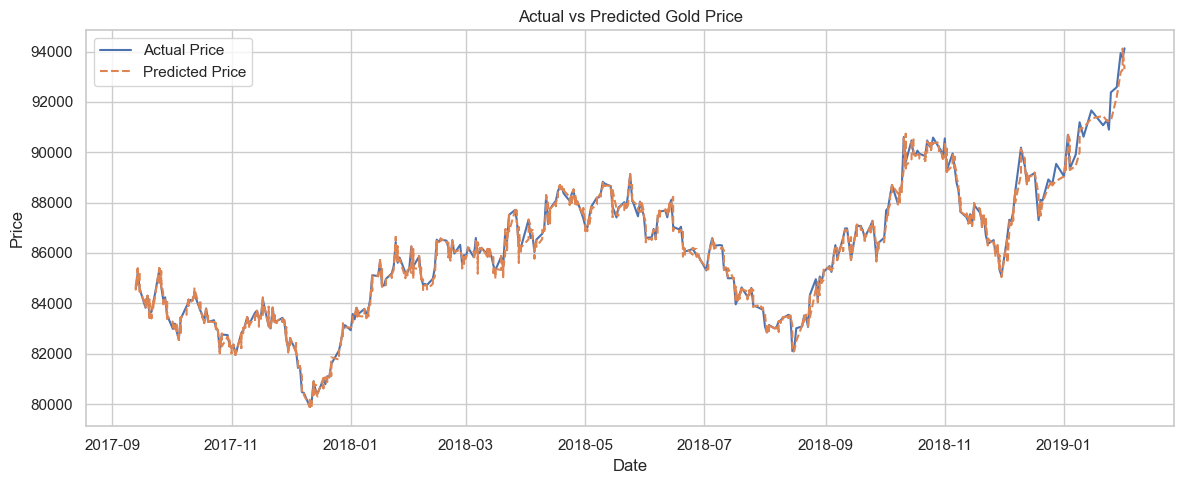

In [27]:
plt.figure(figsize=(12, 5))
plt.plot(comparison_df["Date"], comparison_df["Actual Price"], label="Actual Price")
plt.plot(comparison_df["Date"], comparison_df["Predicted Price"], label="Predicted Price", linestyle="--")
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Actual vs Predicted Gold Price")
plt.legend()
plt.tight_layout()
plt.show()


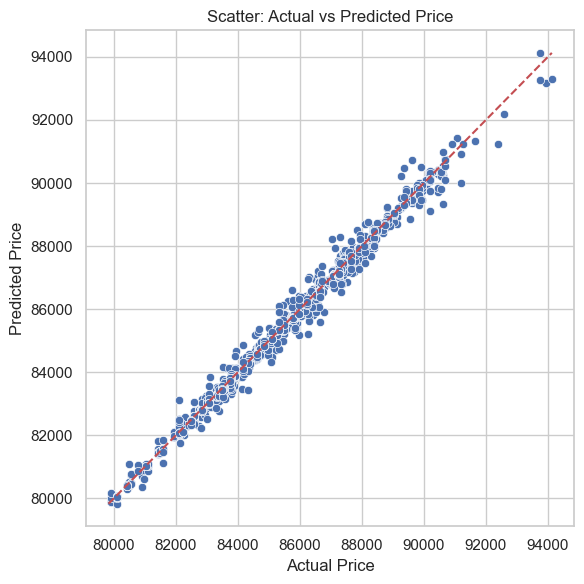

In [28]:
plt.figure(figsize=(6, 6))
sns.scatterplot(x=comparison_df["Actual Price"], y=comparison_df["Predicted Price"])
min_val = min(comparison_df["Actual Price"].min(), comparison_df["Predicted Price"].min())
max_val = max(comparison_df["Actual Price"].max(), comparison_df["Predicted Price"].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Scatter: Actual vs Predicted Price")
plt.tight_layout()
plt.show()


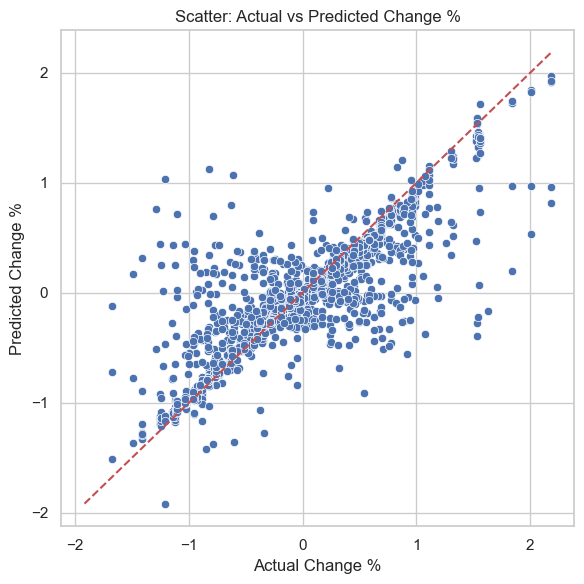

In [29]:
plt.figure(figsize=(6, 6))
sns.scatterplot(x=comparison_df["Actual Change %"], y=comparison_df["Predicted Change %"])
min_val = min(comparison_df["Actual Change %"].min(), comparison_df["Predicted Change %"].min())
max_val = max(comparison_df["Actual Change %"].max(), comparison_df["Predicted Change %"].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')
plt.xlabel("Actual Change %")
plt.ylabel("Predicted Change %")
plt.title("Scatter: Actual vs Predicted Change %")
plt.tight_layout()
plt.show()


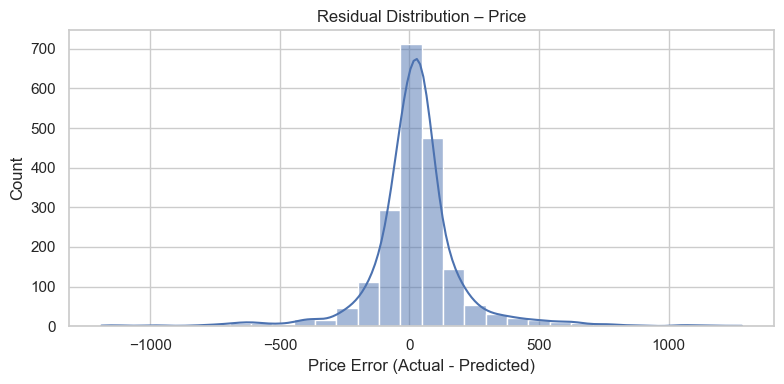

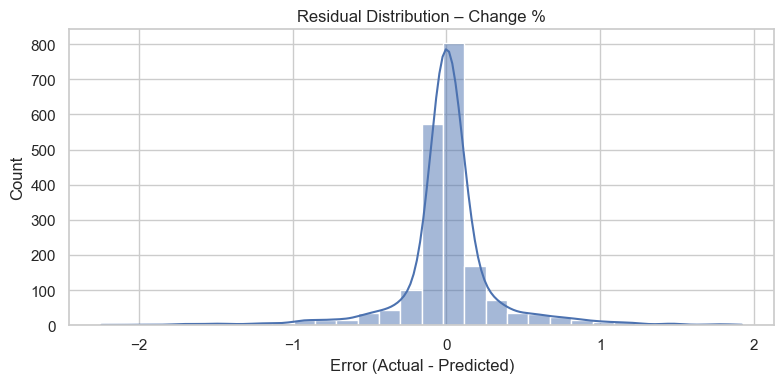

In [30]:
price_residual = comparison_df["Actual Price"] - comparison_df["Predicted Price"]
change_residual = comparison_df["Actual Change %"] - comparison_df["Predicted Change %"]

# Price residual
plt.figure(figsize=(8, 4))
sns.histplot(price_residual, bins=30, kde=True)
plt.title("Residual Distribution – Price")
plt.xlabel("Price Error (Actual - Predicted)")
plt.tight_layout()
plt.show()

# Change % residual
plt.figure(figsize=(8, 4))
sns.histplot(change_residual, bins=30, kde=True)
plt.title("Residual Distribution – Change %")
plt.xlabel("Error (Actual - Predicted)")
plt.tight_layout()
plt.show()


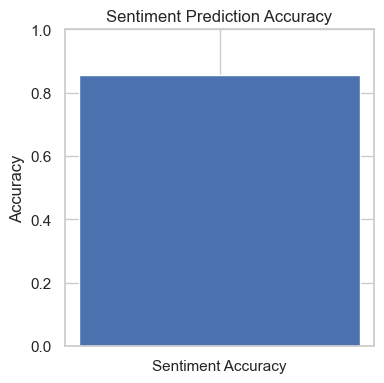

Sentiment Accuracy: 0.8557884231536926


In [31]:
sentiment_accuracy = accuracy_score(comparison_df["Actual Sentiment"], comparison_df["Predicted Sentiment"])

plt.figure(figsize=(4, 4))
plt.bar(["Sentiment Accuracy"], [sentiment_accuracy])
plt.ylim(0, 1)
plt.title("Sentiment Prediction Accuracy")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()

print("Sentiment Accuracy:", sentiment_accuracy)


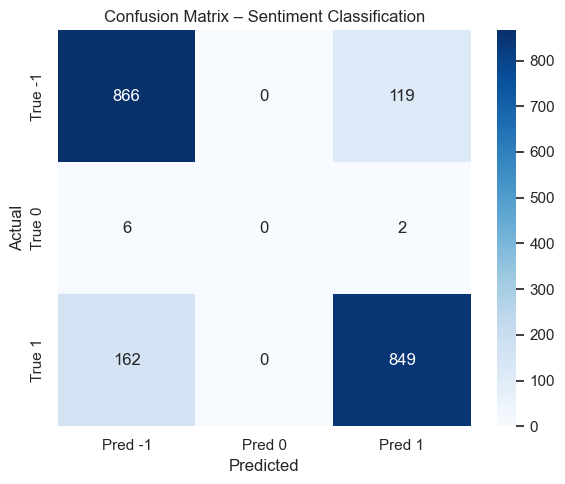

In [32]:
from sklearn.metrics import confusion_matrix

sent_cm = confusion_matrix(
    comparison_df["Actual Sentiment"],
    comparison_df["Predicted Sentiment"],
    labels=[-1, 0, 1]
)

plt.figure(figsize=(6, 5))
sns.heatmap(sent_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred -1", "Pred 0", "Pred 1"],
            yticklabels=["True -1", "True 0", "True 1"])
plt.title("Confusion Matrix – Sentiment Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


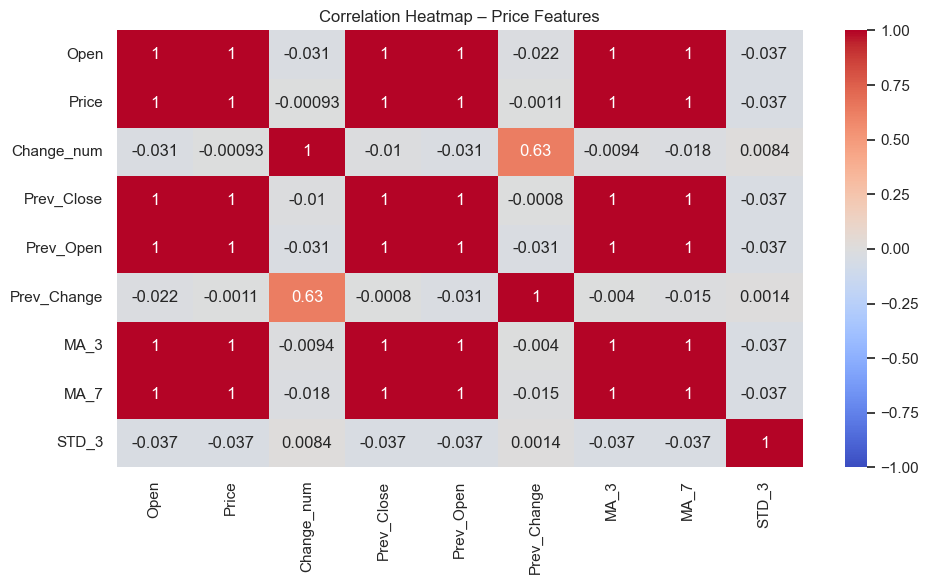

In [33]:
corr = df[["Open","Price","Change_num","Prev_Close","Prev_Open","Prev_Change","MA_3","MA_7","STD_3"]].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap – Price Features")
plt.tight_layout()
plt.show()


In [34]:
print("\n===== FINAL MODEL ACCURACY =====")
print("RMSE Price:", rmse_price)
print("R² Price:", r2_price)
print("RMSE Change %:", rmse_change)
print("R² Change %:", r2_change)
print("Sentiment Accuracy:", sentiment_accuracy)



===== FINAL MODEL ACCURACY =====
RMSE Price: 190.50048978314916
R² Price: 0.9939442268815314
RMSE Change %: 0.33381193184822694
R² Change %: 0.7153760567174019
Sentiment Accuracy: 0.8557884231536926


In [35]:
# Extract original news for the same test rows
original_news_test = data1.loc[test_df.index, "News"].values

# Build comparison table
comparison_df = pd.DataFrame({
    "Date": test_df["Dates"].values,
    "Original News": original_news_test,
    "Cleaned News": test_df["News"].values,
    "Open": test_df["Open"].values,

    "Actual Price": price_true,
    "Predicted Price": price_pred,

    "Actual Change %": change_true,
    "Predicted Change %": change_pred,

    "Actual Sentiment": true_sent,
    "Predicted Sentiment": pred_sent
})

# Sort by Date
comparison_df = comparison_df.sort_values("Date").reset_index(drop=True)

# Optional rounding
comparison_df_round = comparison_df.copy()
comparison_df_round[[
    "Actual Price", "Predicted Price",
    "Actual Change %", "Predicted Change %"
]] = comparison_df_round[[
    "Actual Price", "Predicted Price",
    "Actual Change %", "Predicted Change %"
]].round(2)

comparison_df_round.head(20)


,Date,Original News,Cleaned News,Open,Actual Price,Predicted Price,Actual Change %,Predicted Change %,Actual Sentiment,Predicted Sentiment
0,2017-09-13,gold ends april with modest monthly gain,decemb gold rise oz,85285.0,84597.0,84759.093750,-0.73,-0.20,-1,-1
1,2017-09-13,"Gold locked below $1,300 as market braces for ...",dec gold fall settl oz,85285.0,84597.0,84558.328125,-0.73,-0.68,-1,-1
2,2017-09-13,gold rises as dollar falls ahead of fed announ...,gold rise rs posit global cue,85285.0,84597.0,84598.953125,-0.73,-0.61,-1,-1
3,2017-09-13,"June gold settles at $1,267.20/oz, down $10.30...",gold add slightli earli gain ppi report,85285.0,84597.0,84563.656250,-0.73,-0.66,-1,-1
4,2017-09-13,"gold up 0.5% on day, gains almost 0.9% on week",gold price mark lowest finish month date,85285.0,84597.0,84559.890625,-0.73,-0.74,-1,-1
5,2017-09-13,"metal mania buying keeps silver, gold too hot",gold price finish lower third session row,85285.0,84597.0,84557.546875,-0.73,-0.68,-1,-1
6,2017-09-13,Gold prices turn lower as geopolitical tension...,gold suffer third straight daili declin,85285.0,84597.0,84546.476562,-0.73,-0.74,-1,-1
7,2017-09-14,"Feb. gold settles at $1,193.80/oz, up $12.80, ...",gold futur weak global cue profit book,84701.0,85242.0,85387.882812,0.76,0.71,1,1
8,2017-09-14,Gold inches higher as US-China trade optimism ...,gold extend loss econom report,84701.0,85242.0,85378.367188,0.76,0.68,1,1
9,2017-09-14,eldorado gold withdraws bid for andean resources,dec gold settl oz,84701.0,85242.0,85383.023438,0.76,0.70,1,1


## Interactive Prediction UI (Built Inside Notebook)

Use this section like a mini app:
- Enter a news headline or paragraph.
- Adjust market feature values.
- Click **Predict** to get predicted **Price**, **Change %**, and derived **Sentiment**.

This UI uses your already-trained `model` pipeline in the notebook.

In [36]:
import base64
import io
import re
from pathlib import Path

import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import HTML, clear_output, display

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

APP_STATE = {
    "dashboard_version": 2,
    "batch_result": None,
}

GLOBAL_STYLE = HTML("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Syne:wght@400;600;700;800&family=JetBrains+Mono:wght@400;500&display=swap');
:root {
  --gold:#f5c230; --gold-dark:#a67c00; --bg:#f8f6f1; --card:#ffffff; --muted:#6f6558;
  --text:#1d1812; --border:#e5dccd; --green:#1f7a45; --red:#c23b22; --blue:#1f5fa8;
}
.gfd-root { font-family:'Syne',sans-serif; color:var(--text); }
.gfd-panel { background:var(--card); border:1px solid var(--border); border-radius:16px; padding:20px; box-shadow:0 6px 24px rgba(0,0,0,.06); }
.gfd-header { display:flex; align-items:center; gap:14px; margin-bottom:14px; }
.gfd-icon { width:48px; height:48px; border-radius:14px; display:flex; align-items:center; justify-content:center; background:linear-gradient(135deg,#ffe08a,var(--gold-dark)); font-size:22px; }
.gfd-title { margin:0; font-size:1.35rem; font-weight:800; }
.gfd-sub { margin:2px 0 0 0; color:var(--muted); font-family:'JetBrains Mono',monospace; font-size:.78rem; }
.gfd-status { margin-top:10px; padding:10px 12px; border-radius:10px; font-family:'JetBrains Mono',monospace; font-size:.8rem; }
.gfd-status.ok { background:rgba(31,122,69,.1); color:var(--green); border:1px solid rgba(31,122,69,.25); }
.gfd-status.error { background:rgba(194,59,34,.1); color:var(--red); border:1px solid rgba(194,59,34,.25); }
.gfd-status.info { background:rgba(31,95,168,.1); color:var(--blue); border:1px solid rgba(31,95,168,.25); }
.gfd-note { background:rgba(245,194,48,.12); border:1px solid rgba(245,194,48,.3); padding:10px 12px; border-radius:10px; color:var(--muted); font-size:.82rem; }
.gfd-result { margin-top:12px; padding:16px; border:1px solid rgba(245,194,48,.4); border-radius:14px; background:rgba(245,194,48,.08); }
.gfd-result-grid { display:grid; grid-template-columns:repeat(4,1fr); gap:12px; }
.gfd-label { color:var(--muted); font-size:.74rem; text-transform:uppercase; letter-spacing:.06em; font-weight:700; }
.gfd-value { font-family:'JetBrains Mono',monospace; font-size:1.08rem; font-weight:600; }
.gfd-big { font-size:1.32rem; color:var(--gold-dark); }
.gfd-badge { display:inline-flex; align-items:center; padding:5px 10px; border-radius:999px; font-size:.78rem; font-weight:700; }
.gfd-bull { color:var(--green); background:rgba(31,122,69,.12); }
.gfd-bear { color:var(--red); background:rgba(194,59,34,.12); }
.gfd-flat { color:var(--gold-dark); background:rgba(245,194,48,.16); }
.gfd-metrics { display:grid; grid-template-columns:repeat(auto-fit, minmax(160px,1fr)); gap:12px; }
.gfd-metric { background:#fbfaf7; border:1px solid var(--border); border-radius:12px; padding:14px; }
.gfd-metric-name { color:var(--muted); font-size:.72rem; text-transform:uppercase; letter-spacing:.06em; font-weight:700; }
.gfd-metric-value { font-family:'JetBrains Mono',monospace; font-size:1.18rem; font-weight:700; margin-top:6px; }
.gfd-dl a { display:inline-block; margin-top:10px; padding:10px 14px; border-radius:10px; border:1px solid var(--border); text-decoration:none; color:var(--text); background:#fbfaf7; }
</style>
""")

POSITIVE_GOLD_TERMS = [
    "safe haven", "uncertainty", "inflation", "trade war", "conflict", "war", "geopolitical",
    "recession fears", "stock markets tumble", "etf inflows", "gold reserves", "rupee weakens",
    "dollar falls", "dollar weakens", "currency volatility", "crisis"
]
NEGATIVE_GOLD_TERMS = [
    "rate hike", "raises interest rates", "further hikes", "dollar surges", "strong jobs data",
    "equity markets rally", "outflows", "ceasefire", "peace deal", "gdp growth beats",
    "growth forecast", "risk on", "investor confidence", "bitcoin surges"
]


def get_text_cleaner():
    global_clean_text = globals().get("clean_text")
    stop_set = globals().get("stop_words")
    stemmer = globals().get("ps")

    if callable(global_clean_text):
        return global_clean_text

    if stop_set is not None and stemmer is not None:
        def cleaner(text):
            text = str(text).lower()
            text = re.sub(r"[^a-zA-Z\s]", " ", text)
            words = text.split()
            words = [stemmer.stem(word) for word in words if word not in stop_set]
            return " ".join(words)
        return cleaner

    def fallback_cleaner(text):
        text = str(text).lower()
        text = re.sub(r"[^a-zA-Z\s]", " ", text)
        text = re.sub(r"\s+", " ", text).strip()
        return text

    return fallback_cleaner


TEXT_CLEANER = get_text_cleaner()


def clean_text_local(text: str) -> str:
    return TEXT_CLEANER(text)


def change_to_sentiment_local(value: float) -> int:
    if value > 0:
        return 1
    if value < 0:
        return -1
    return 0


def heuristic_gold_sentiment(headline: str):
    text = str(headline).lower()
    pos_score = sum(1 for term in POSITIVE_GOLD_TERMS if term in text)
    neg_score = sum(1 for term in NEGATIVE_GOLD_TERMS if term in text)
    score = pos_score - neg_score
    if score >= 2:
        return 1, score, "headline heuristic"
    if score <= -2:
        return -1, score, "headline heuristic"
    return 0, score, "model"


def class_to_label(sentiment_class: int):
    if sentiment_class > 0:
        return "Bullish", "+1", "gfd-bull"
    if sentiment_class < 0:
        return "Bearish", "-1", "gfd-bear"
    return "Neutral", "0", "gfd-flat"


def combine_sentiment(headline: str, model_class: int):
    heuristic_class, heuristic_score, source = heuristic_gold_sentiment(headline)
    final_class = heuristic_class if heuristic_class != 0 else int(model_class)
    if heuristic_class != 0 and heuristic_class != int(model_class):
        source = f"headline heuristic override (score {heuristic_score:+d})"
    elif heuristic_class != 0:
        source = f"model + headline heuristic (score {heuristic_score:+d})"
    else:
        source = "sentiment classifier"
    return final_class, source


def ensure_artifacts(force_rebuild: bool = False):
    needed = [
        "model", "sentiment_model", "df", "feature_cols_num",
        "X_test", "y_test", "sentiment_test", "rmse_price", "r2_price",
        "rmse_change", "r2_change", "sentiment_accuracy", "model_version"
    ]
    if (not force_rebuild) and all(name in globals() for name in needed) and globals().get("model_version") == 2:
        return True, "Using corrected regression + sentiment models from notebook state."

    cwd = Path.cwd()
    market_candidates = [cwd / "XAU_INR Historical Data.csv", cwd / "XAU_INR Historical Data (1).csv"]
    news_candidates = [cwd / "gold-dataset-sinha-khandait.csv"]

    market_path = next((path for path in market_candidates if path.exists()), None)
    news_path = next((path for path in news_candidates if path.exists()), None)
    if market_path is None or news_path is None:
        return False, "Required CSV files not found in current directory."

    market_df = pd.read_csv(market_path)
    news_df = pd.read_csv(news_path)

    news_df["Dates"] = pd.to_datetime(
        news_df["Dates"].astype(str).str.strip(),
        format="%d-%m-%Y",
        errors="coerce",
    )

    if "Date" in market_df.columns:
        market_df["Date"] = pd.to_datetime(
            market_df["Date"].astype(str).str.strip(),
            format="%m/%d/%Y",
            errors="coerce",
        )
        market_df = market_df.rename(columns={"Date": "Dates"})

    market_df["Dates"] = pd.to_datetime(market_df["Dates"], errors="coerce")
    data = pd.merge(news_df, market_df, on="Dates", how="inner")

    data["Price"] = data["Price"].astype(str).str.replace(",", "", regex=False).astype(float)
    data["Open"] = data["Open"].astype(str).str.replace(",", "", regex=False).astype(float)
    data["News"] = data["News"].astype(str)
    data["Cleaned News"] = data["News"].apply(clean_text_local)
    data["Change_num"] = (
        data["Change %"].astype(str).str.replace("%", "", regex=False).str.strip().replace("", np.nan).astype(float)
    )

    sentiment_map = {"negative": -1, "neutral": 0, "positive": 1, "none": 0}
    if "Price Sentiment" in data.columns:
        data["SentimentClass"] = data["Price Sentiment"].astype(str).str.lower().map(lambda value: sentiment_map.get(value, 0))
    else:
        data["SentimentClass"] = data["Change_num"].apply(change_to_sentiment_local)

    data = data.sort_values("Dates").reset_index(drop=True)
    data["Year"] = data["Dates"].dt.year
    data["Month"] = data["Dates"].dt.month
    data["Day"] = data["Dates"].dt.day
    data["Prev_Close"] = data["Price"].shift(1)
    data["Prev_Open"] = data["Open"].shift(1)
    data["Prev_Change"] = data["Change_num"].shift(1)
    data["MA_3"] = data["Price"].rolling(window=3).mean()
    data["MA_7"] = data["Price"].rolling(window=7).mean()
    data["STD_3"] = data["Price"].rolling(window=3).std()

    data = data.dropna(subset=[
        "Cleaned News", "Open", "Price", "Change_num", "SentimentClass",
        "Prev_Close", "Prev_Open", "Prev_Change", "MA_3", "MA_7", "STD_3", "Dates"
    ]).reset_index(drop=True)

    feature_cols = ["Open", "Prev_Close", "Prev_Open", "Prev_Change", "MA_3", "MA_7", "STD_3", "Year", "Month", "Day"]
    features = data[["Cleaned News"] + feature_cols].rename(columns={"Cleaned News": "News"})
    regression_target = data[["Price", "Change_num"]]
    sentiment_target = data["SentimentClass"]

    split_idx = int(len(data) * 0.8)
    X_train = features.iloc[:split_idx].copy()
    X_test_local = features.iloc[split_idx:].copy()
    y_train_reg = regression_target.iloc[:split_idx].copy()
    y_test_reg = regression_target.iloc[split_idx:].copy()
    y_train_cls = sentiment_target.iloc[:split_idx].copy()
    y_test_cls = sentiment_target.iloc[split_idx:].copy()

    reg_preprocess = ColumnTransformer([
        ("text", TfidfVectorizer(max_features=8000, ngram_range=(1, 2), min_df=3, max_df=0.95), "News"),
        ("num", "passthrough", feature_cols),
    ])
    cls_preprocess = ColumnTransformer([
        ("text", TfidfVectorizer(max_features=8000, ngram_range=(1, 2), min_df=2, max_df=0.98), "News"),
        ("num", "passthrough", feature_cols),
    ])

    reg_model = Pipeline([
        ("preprocess", reg_preprocess),
        ("regressor", RandomForestRegressor(
            n_estimators=400,
            min_samples_leaf=2,
            n_jobs=-1,
            random_state=42,
        )),
    ])

    cls_model = Pipeline([
        ("preprocess", cls_preprocess),
        ("classifier", RandomForestClassifier(
            n_estimators=500,
            min_samples_leaf=2,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=42,
        )),
    ])

    reg_model.fit(X_train, y_train_reg)
    cls_model.fit(X_train, y_train_cls)

    reg_preds = reg_model.predict(X_test_local)
    cls_preds = cls_model.predict(X_test_local)

    globals().update({
        "df": data,
        "feature_cols_num": feature_cols,
        "model": reg_model,
        "sentiment_model": cls_model,
        "X_test": X_test_local,
        "y_test": y_test_reg,
        "sentiment_test": y_test_cls,
        "rmse_price": float(np.sqrt(mean_squared_error(y_test_reg["Price"].values, reg_preds[:, 0]))),
        "r2_price": float(r2_score(y_test_reg["Price"].values, reg_preds[:, 0])),
        "rmse_change": float(np.sqrt(mean_squared_error(y_test_reg["Change_num"].values, reg_preds[:, 1]))),
        "r2_change": float(r2_score(y_test_reg["Change_num"].values, reg_preds[:, 1])),
        "sentiment_accuracy": float(accuracy_score(y_test_cls, cls_preds)),
        "model_version": 2,
    })

    return True, "Corrected regression and sentiment models are ready."


def make_download_html(df_result: pd.DataFrame, filename: str = "gold_batch_predictions.csv"):
    encoded = base64.b64encode(df_result.to_csv(index=False).encode("utf-8")).decode()
    return HTML(
        f'<div class="gfd-dl"><a download="{filename}" href="data:text/csv;base64,{encoded}" target="_blank">Download predictions CSV</a></div>'
    )


def launch_dashboard(output_area):
    if "model" not in globals() or "sentiment_model" not in globals() or globals().get("model_version") != 2:
        with output_area:
            clear_output(wait=True)
            display(HTML('<div class="gfd-root"><div class="gfd-status error">Corrected model is not ready yet. Click Launch Dashboard.</div></div>'))
        return

    latest = df.iloc[-1]

    def _default_num(column_name, fallback=0.0):
        try:
            value = float(latest.get(column_name, fallback))
            return float(fallback) if np.isnan(value) else value
        except Exception:
            return float(fallback)

    news_input = widgets.Textarea(
        value="US Federal Reserve raises interest rates aggressively by 75 basis points signaling further hikes ahead reducing gold appeal",
        layout=widgets.Layout(width="100%", height="110px")
    )
    date_input = widgets.DatePicker(layout=widgets.Layout(width="100%"))

    def make_float(value):
        return widgets.FloatText(value=value, layout=widgets.Layout(width="100%"))

    open_w = make_float(_default_num("Open"))
    prev_close_w = make_float(_default_num("Prev_Close"))
    prev_open_w = make_float(_default_num("Prev_Open"))
    prev_change_w = make_float(_default_num("Prev_Change"))
    ma3_w = make_float(_default_num("MA_3"))
    ma7_w = make_float(_default_num("MA_7"))
    std3_w = make_float(_default_num("STD_3"))

    single_out = widgets.Output()
    batch_out = widgets.Output()
    metrics_out = widgets.Output()

    def build_single_input():
        selected_date = pd.Timestamp(date_input.value) if date_input.value else pd.Timestamp.today()
        cleaned_news = clean_text_local(news_input.value)
        return pd.DataFrame([{
            "News": cleaned_news,
            "Open": float(open_w.value),
            "Prev_Close": float(prev_close_w.value),
            "Prev_Open": float(prev_open_w.value),
            "Prev_Change": float(prev_change_w.value),
            "MA_3": float(ma3_w.value),
            "MA_7": float(ma7_w.value),
            "STD_3": float(std3_w.value),
            "Year": int(selected_date.year),
            "Month": int(selected_date.month),
            "Day": int(selected_date.day),
        }])

    def on_predict(_):
        with single_out:
            clear_output(wait=True)
            try:
                input_df = build_single_input()
                reg_pred = model.predict(input_df)[0]
                cls_pred = int(sentiment_model.predict(input_df)[0])
                final_class, source = combine_sentiment(news_input.value, cls_pred)
                sentiment_label, class_label, badge_class = class_to_label(final_class)
                price_pred = float(reg_pred[0])
                change_pred = float(reg_pred[1])
                change_color = "var(--green)" if change_pred > 0 else "var(--red)" if change_pred < 0 else "var(--muted)"
                display(HTML(f"""
                <div class="gfd-root">
                  <div class="gfd-result">
                    <div class="gfd-result-grid">
                      <div><div class="gfd-label">Predicted Price</div><div class="gfd-value gfd-big">₹{price_pred:,.2f}</div></div>
                      <div><div class="gfd-label">Predicted Change %</div><div class="gfd-value" style="color:{change_color}">{change_pred:+.4f}%</div></div>
                      <div><div class="gfd-label">Final Sentiment</div><div class="gfd-value">{sentiment_label}</div></div>
                      <div><div class="gfd-label">Sentiment Class</div><div class="gfd-badge {badge_class}">{class_label}</div></div>
                    </div>
                    <div class="gfd-status info">Source: {source}. The UI now uses a dedicated sentiment classifier instead of only the regression sign.</div>
                  </div>
                </div>
                """))
            except Exception as ex:
                display(HTML(f'<div class="gfd-root"><div class="gfd-status error">Prediction failed: {ex}</div></div>'))

    def on_reset(_):
        open_w.value = _default_num("Open")
        prev_close_w.value = _default_num("Prev_Close")
        prev_open_w.value = _default_num("Prev_Open")
        prev_change_w.value = _default_num("Prev_Change")
        ma3_w.value = _default_num("MA_3")
        ma7_w.value = _default_num("MA_7")
        std3_w.value = _default_num("STD_3")
        with single_out:
            clear_output(wait=True)
            display(HTML('<div class="gfd-root"><div class="gfd-status info">Inputs reset to latest dataset defaults.</div></div>'))

    predict_btn = widgets.Button(description="Run Prediction", layout=widgets.Layout(width="auto"))
    predict_btn.style.button_color = "#f5c230"
    reset_btn = widgets.Button(description="Reset", layout=widgets.Layout(width="auto"))
    predict_btn.on_click(on_predict)
    reset_btn.on_click(on_reset)

    upload = widgets.FileUpload(accept=".csv", multiple=False)
    batch_btn = widgets.Button(description="Run Batch Prediction", layout=widgets.Layout(width="auto"))
    batch_btn.style.button_color = "#1f5fa8"
    required_cols = ["News", "Open", "Prev_Close", "Prev_Open", "Prev_Change", "MA_3", "MA_7", "STD_3"]

    def extract_uploaded_bytes(value):
        if not value:
            return None
        if isinstance(value, dict):
            item = next(iter(value.values()))
            return item.get("content")
        try:
            item = value[0]
            return item.get("content") if isinstance(item, dict) else getattr(item, "content", None)
        except Exception:
            return None

    def on_batch(_):
        with batch_out:
            clear_output(wait=True)
            raw = extract_uploaded_bytes(upload.value)
            if raw is None:
                display(HTML('<div class="gfd-root"><div class="gfd-status error">Upload a CSV first.</div></div>'))
                return
            try:
                batch_df = pd.read_csv(io.BytesIO(raw))
            except Exception as ex:
                display(HTML(f'<div class="gfd-root"><div class="gfd-status error">Cannot read CSV: {ex}</div></div>'))
                return

            missing_cols = [column for column in required_cols if column not in batch_df.columns]
            if missing_cols:
                display(HTML(f'<div class="gfd-root"><div class="gfd-status error">Missing columns: {missing_cols}</div></div>'))
                return

            work_df = batch_df.copy()
            raw_news = work_df["News"].astype(str).tolist()
            work_df["News"] = work_df["News"].astype(str).apply(clean_text_local)
            if "Date" in work_df.columns:
                parsed_dates = pd.to_datetime(work_df["Date"], errors="coerce")
            elif "Dates" in work_df.columns:
                parsed_dates = pd.to_datetime(work_df["Dates"], errors="coerce")
            else:
                parsed_dates = pd.Series([pd.Timestamp.today()] * len(work_df))
            parsed_dates = parsed_dates.fillna(pd.Timestamp.today())
            work_df["Year"] = parsed_dates.dt.year.astype(int)
            work_df["Month"] = parsed_dates.dt.month.astype(int)
            work_df["Day"] = parsed_dates.dt.day.astype(int)

            model_input = work_df[["News"] + feature_cols_num]
            reg_preds = model.predict(model_input)
            cls_preds = sentiment_model.predict(model_input)

            final_classes = [combine_sentiment(headline, model_class)[0] for headline, model_class in zip(raw_news, cls_preds)]
            result = batch_df.copy()
            result["Predicted Price"] = reg_preds[:, 0]
            result["Predicted Change %"] = reg_preds[:, 1]
            result["Predicted Sentiment Class"] = final_classes
            result["Predicted Sentiment"] = [class_to_label(value)[0] for value in final_classes]
            result["Model Sentiment Class"] = cls_preds

            APP_STATE["batch_result"] = result
            display(HTML(f'<div class="gfd-root"><div class="gfd-status ok">Processed {len(result):,} rows with corrected sentiment model.</div></div>'))
            display(result.head(20))
            display(make_download_html(result))

    batch_btn.on_click(on_batch)

    with metrics_out:
        clear_output(wait=True)
        display(HTML(f"""
        <div class="gfd-root">
          <div class="gfd-metrics">
            <div class="gfd-metric"><div class="gfd-metric-name">RMSE Price</div><div class="gfd-metric-value">{float(rmse_price):,.2f}</div></div>
            <div class="gfd-metric"><div class="gfd-metric-name">R2 Price</div><div class="gfd-metric-value">{float(r2_price):.4f}</div></div>
            <div class="gfd-metric"><div class="gfd-metric-name">RMSE Change %</div><div class="gfd-metric-value">{float(rmse_change):.4f}</div></div>
            <div class="gfd-metric"><div class="gfd-metric-name">R2 Change %</div><div class="gfd-metric-value">{float(r2_change):.4f}</div></div>
            <div class="gfd-metric"><div class="gfd-metric-name">Sentiment Accuracy</div><div class="gfd-metric-value">{float(sentiment_accuracy) * 100:.1f}%</div></div>
          </div>
        </div>
        """))

    single_tab = widgets.VBox([
        widgets.HTML('<div class="gfd-root gfd-note">Single prediction now uses cleaned text that matches training preprocessing, plus a separate sentiment classifier.</div>'),
        widgets.HTML('<div class="gfd-root"><div class="gfd-label">Headline / News Excerpt</div></div>'),
        news_input,
        widgets.HTML('<div class="gfd-root"><div class="gfd-label">Prediction Date</div></div>'),
        date_input,
        widgets.HBox([
            widgets.VBox([widgets.HTML('<div class="gfd-root"><div class="gfd-label">Open</div></div>'), open_w], layout=widgets.Layout(width="33%")),
            widgets.VBox([widgets.HTML('<div class="gfd-root"><div class="gfd-label">Prev Close</div></div>'), prev_close_w], layout=widgets.Layout(width="33%")),
            widgets.VBox([widgets.HTML('<div class="gfd-root"><div class="gfd-label">Prev Open</div></div>'), prev_open_w], layout=widgets.Layout(width="33%")),
        ], layout=widgets.Layout(gap="10px")),
        widgets.HBox([
            widgets.VBox([widgets.HTML('<div class="gfd-root"><div class="gfd-label">Prev Change</div></div>'), prev_change_w], layout=widgets.Layout(width="33%")),
            widgets.VBox([widgets.HTML('<div class="gfd-root"><div class="gfd-label">MA 3</div></div>'), ma3_w], layout=widgets.Layout(width="33%")),
            widgets.VBox([widgets.HTML('<div class="gfd-root"><div class="gfd-label">MA 7</div></div>'), ma7_w], layout=widgets.Layout(width="33%")),
        ], layout=widgets.Layout(gap="10px")),
        widgets.VBox([widgets.HTML('<div class="gfd-root"><div class="gfd-label">STD 3</div></div>'), std3_w], layout=widgets.Layout(width="33%")),
        widgets.HBox([predict_btn, reset_btn], layout=widgets.Layout(gap="10px")),
        single_out,
    ])

    batch_tab = widgets.VBox([
        widgets.HTML('<div class="gfd-root gfd-note">Required CSV columns: News, Open, Prev_Close, Prev_Open, Prev_Change, MA_3, MA_7, STD_3. Optional: Date or Dates.</div>'),
        upload,
        batch_btn,
        batch_out,
    ])

    metrics_tab = widgets.VBox([metrics_out])

    tabs = widgets.Tab(children=[single_tab, batch_tab, metrics_tab])
    tabs.set_title(0, "Single Prediction")
    tabs.set_title(1, "Batch Prediction")
    tabs.set_title(2, "Metrics")

    with output_area:
        clear_output(wait=True)
        display(GLOBAL_STYLE)
        display(HTML("""
        <div class="gfd-root">
          <div class="gfd-panel">
            <div class="gfd-header">
              <div class="gfd-icon">🪙</div>
              <div>
                <h2 class="gfd-title">Gold Forecast Dashboard</h2>
                <p class="gfd-sub">Corrected sentiment pipeline with dedicated classifier and single dashboard render.</p>
              </div>
            </div>
          </div>
        </div>
        """))
        display(tabs)


display(GLOBAL_STYLE)
helper_out = widgets.Output()
dashboard_out = widgets.Output()
launch_btn = widgets.Button(description="Launch Dashboard", layout=widgets.Layout(width="220px", height="40px"))
launch_btn.style.button_color = "#f5c230"
rebuild_chk = widgets.Checkbox(value=True, description="Force rebuild corrected model", indent=False)


def on_launch(_):
    with helper_out:
        clear_output(wait=True)
        display(HTML('<div class="gfd-root"><div class="gfd-status info">Building corrected regression and sentiment models...</div></div>'))
    ok, message = ensure_artifacts(force_rebuild=rebuild_chk.value)
    with helper_out:
        clear_output(wait=True)
        css_class = "ok" if ok else "error"
        display(HTML(f'<div class="gfd-root"><div class="gfd-status {css_class}">{message}</div></div>'))
    if ok:
        launch_dashboard(dashboard_out)


launch_btn.on_click(on_launch)

display(HTML("""
<div class="gfd-root">
  <div class="gfd-panel">
    <div class="gfd-header">
      <div class="gfd-icon">🚀</div>
      <div>
        <h2 class="gfd-title">Dashboard Launcher</h2>
        <p class="gfd-sub">Build the corrected model once, then use the single dashboard below.</p>
      </div>
    </div>
  </div>
</div>
"""))
display(widgets.HBox([launch_btn, rebuild_chk], layout=widgets.Layout(gap="14px", align_items="center")))
display(helper_out)
display(dashboard_out)

Output()

Output()